In [1]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
from tqdm import tqdm_notebook
from itertools import product
from typing import Union
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings ('ignore')
%matplotlib inline

In [2]:
met_1 = pd.read_csv("met_data1_cleaned.csv")
met_2 = pd.read_csv("met_data2_cleaned.csv")
met_3 = pd.read_csv("met_data3_cleaned.csv")
met_4 = pd.read_csv("met_data4_cleaned.csv")
met_5 = pd.read_csv("met_data5_cleaned.csv")
met_6 = pd.read_csv("met_data6_cleaned.csv")


met_1 = met_1.dropna()
met_2 = met_2.dropna()
met_3 = met_3.dropna()
met_4 = met_4.dropna()
met_5 = met_5.dropna()
met_6 = met_6.dropna()

In [3]:
print(met_1.shape)
print(met_2.shape)
print(met_3.shape)
print(met_4.shape)
print(met_5.shape)
print(met_6.shape)

(59795, 7)
(57711, 7)
(58878, 7)
(58859, 7)
(58854, 7)
(58380, 7)


In [4]:
met_1

,Date,Ppt,Tair,RH,Windspeed,Winddirection,Srad
0,2014-10-01 00:00:00,0.0,22.130,80.70,1.429,203.2,0.00
1,2014-10-01 01:00:00,0.0,21.680,84.70,1.555,201.2,0.00
2,2014-10-01 02:00:00,0.0,22.210,89.20,2.288,193.1,0.00
3,2014-10-01 03:00:00,0.0,22.410,90.00,2.421,195.4,0.00
4,2014-10-01 04:00:00,0.0,22.300,92.60,1.738,191.3,0.00
...,...,...,...,...,...,...,...
60641,2021-08-31 17:00:00,0.0,33.130,44.25,2.201,151.4,221.80
60642,2021-08-31 18:00:00,0.0,32.840,48.30,2.410,174.2,157.60
60643,2021-08-31 19:00:00,0.0,30.970,55.31,1.385,186.5,23.12
60644,2021-08-31 20:00:00,0.0,29.100,60.19,1.029,197.1,0.00


### Visualize the data of air temperature with timeseries

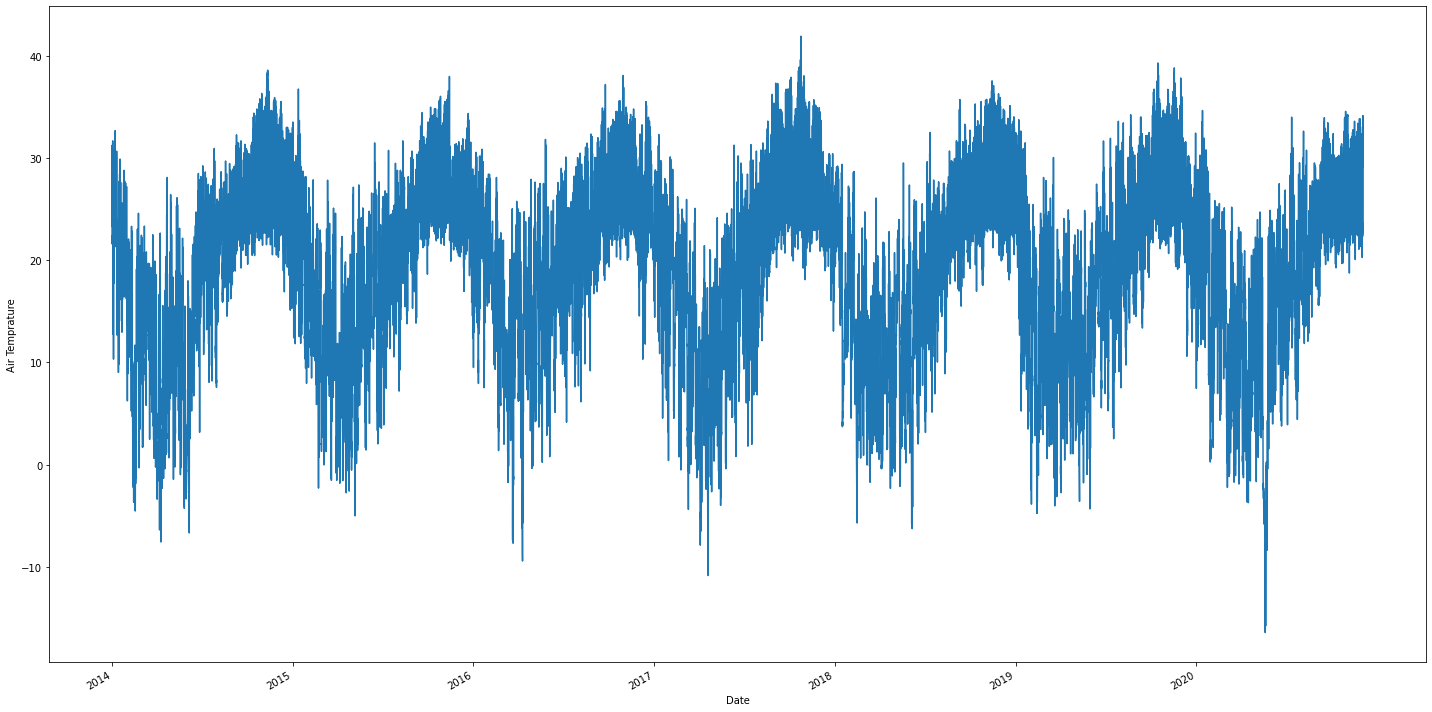

In [5]:
fig, ax = plt.subplots(figsize=(20,10))
ax.plot(met_1.Tair)
ax.set_xlabel("Date")
ax.set_ylabel("Air Temprature")
plt.xticks(np.arange(0, 60649, 8760), np.arange(2014, 2021, 1))
fig.autofmt_xdate()
plt.tight_layout()

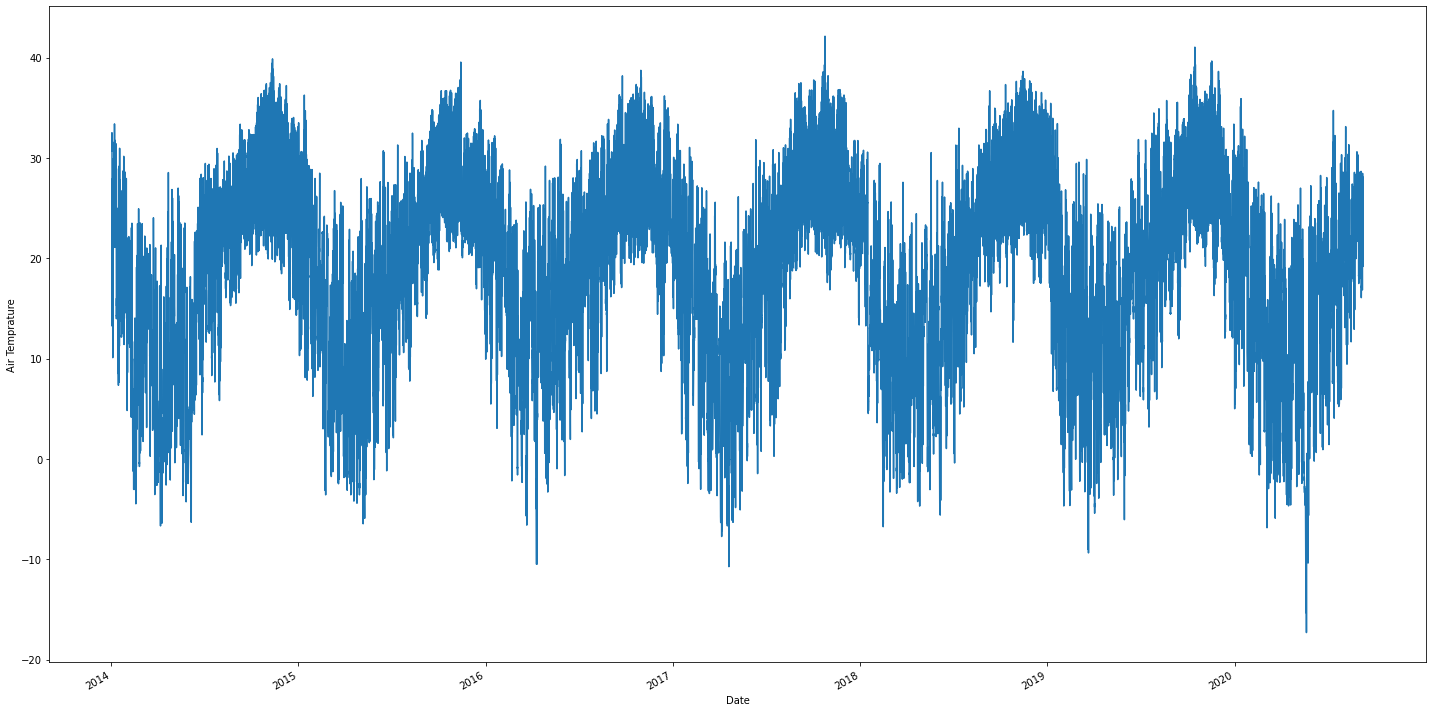

In [6]:
fig, ax = plt.subplots(figsize=(20,10))
ax.plot(met_2.Tair)
ax.set_xlabel("Date")
ax.set_ylabel("Air Temprature")
plt.xticks(np.arange(0, 60649, 8760), np.arange(2014, 2021, 1))
fig.autofmt_xdate()
plt.tight_layout()

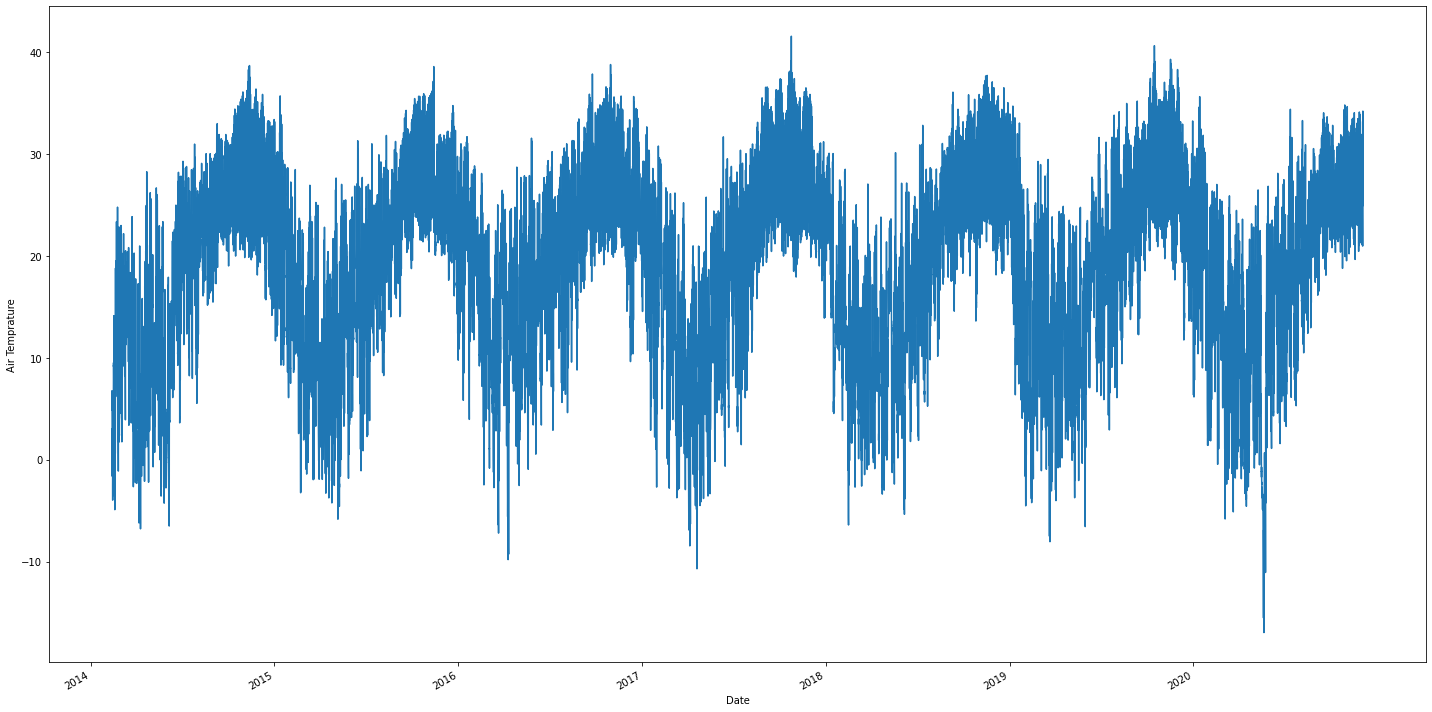

In [7]:
fig, ax = plt.subplots(figsize=(20,10))
ax.plot(met_3.Tair)
ax.set_xlabel("Date")
ax.set_ylabel("Air Temprature")
plt.xticks(np.arange(0, 60649, 8760), np.arange(2014, 2021, 1))
fig.autofmt_xdate()
plt.tight_layout()

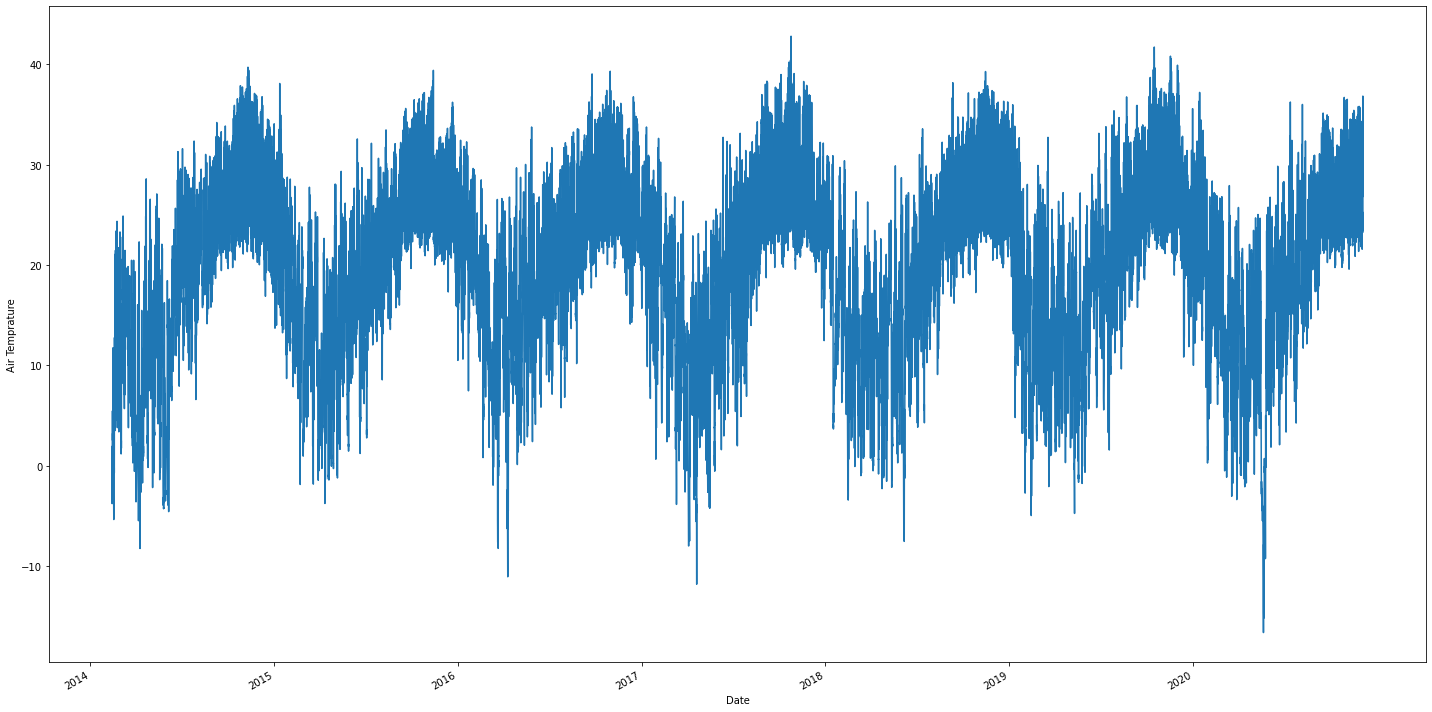

In [8]:
fig, ax = plt.subplots(figsize=(20,10))
ax.plot(met_4.Tair)
ax.set_xlabel("Date")
ax.set_ylabel("Air Temprature")
plt.xticks(np.arange(0, 60649, 8760), np.arange(2014, 2021, 1))
fig.autofmt_xdate()
plt.tight_layout()

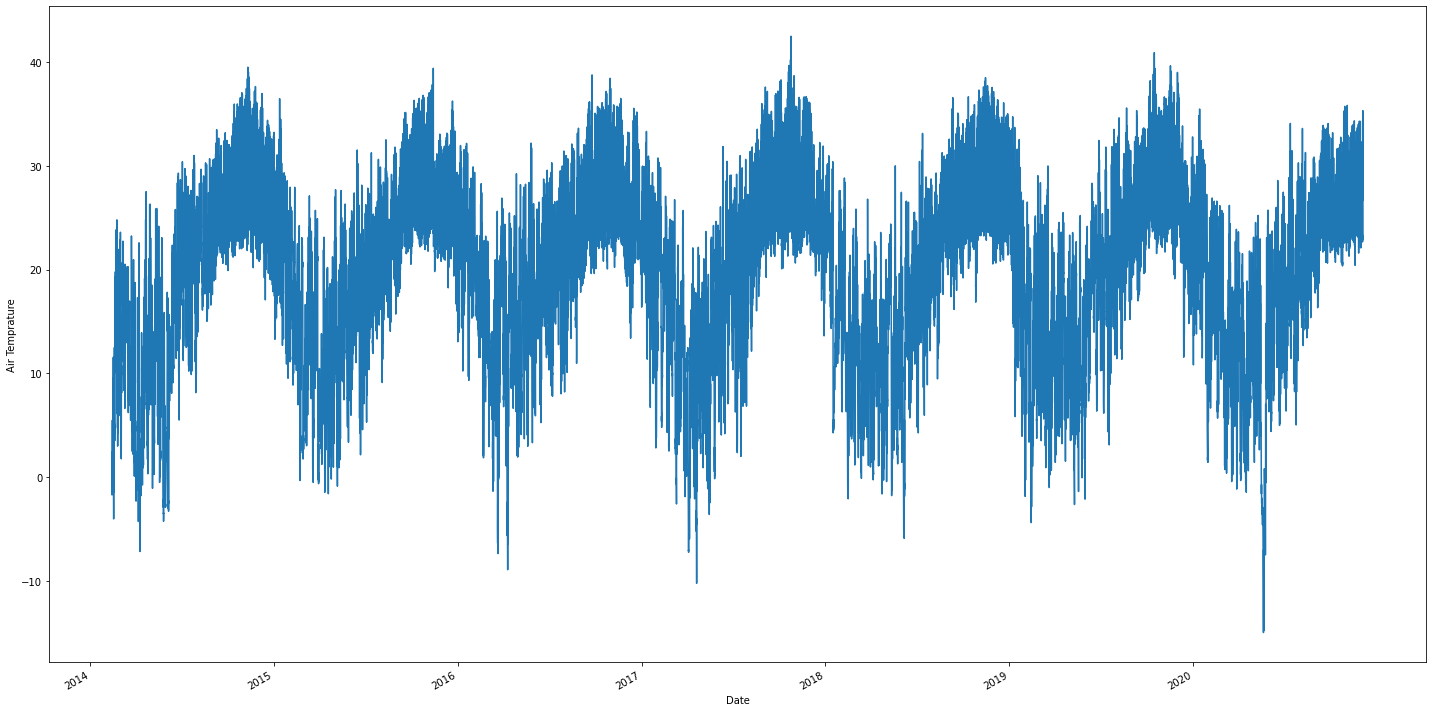

In [9]:
fig, ax = plt.subplots(figsize=(20,10))
ax.plot(met_5.Tair)
ax.set_xlabel("Date")
ax.set_ylabel("Air Temprature")
plt.xticks(np.arange(0, 60649, 8760), np.arange(2014, 2021, 1))
fig.autofmt_xdate()
plt.tight_layout()

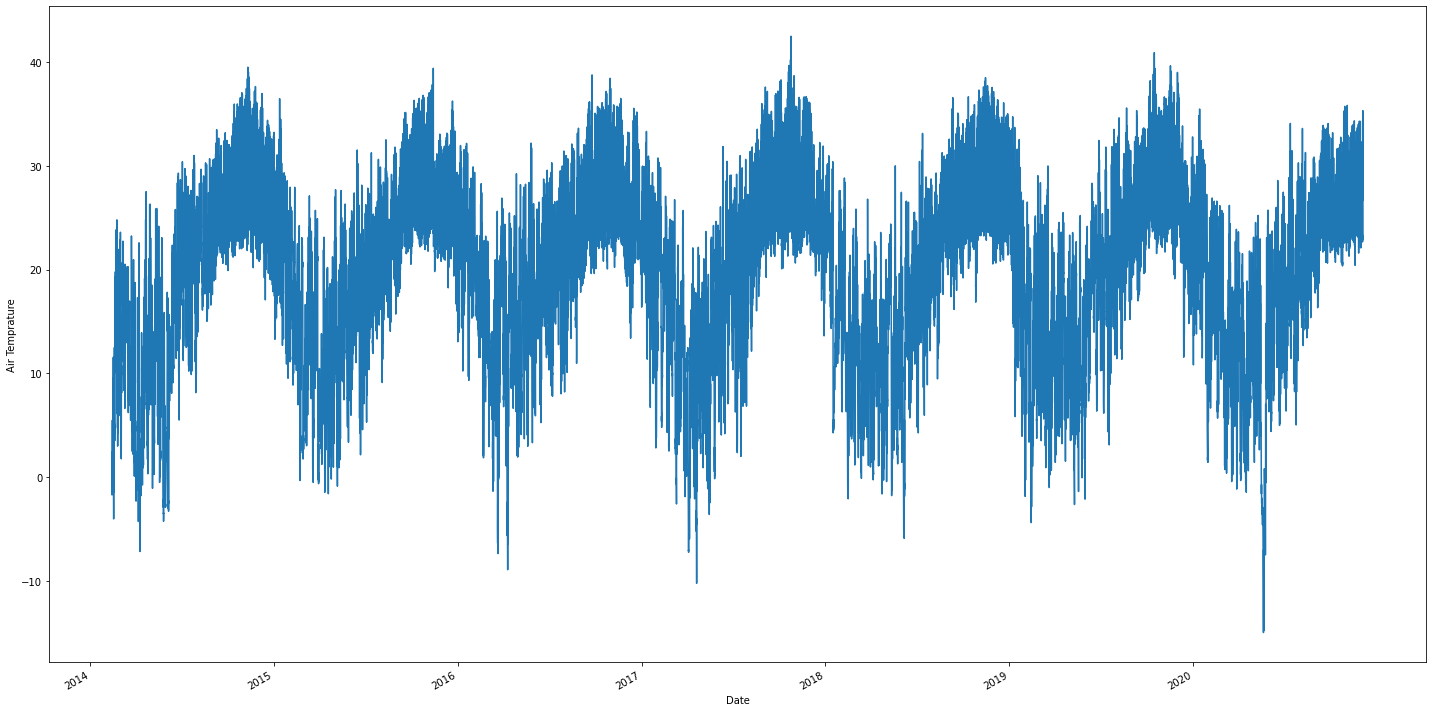

In [10]:
fig, ax = plt.subplots(figsize=(20,10))
ax.plot(met_5.Tair)
ax.set_xlabel("Date")
ax.set_ylabel("Air Temprature")
plt.xticks(np.arange(0, 60649, 8760), np.arange(2014, 2021, 1))
fig.autofmt_xdate()
plt.tight_layout()

### Build up STL model for temperature data of each station

#### Station 1

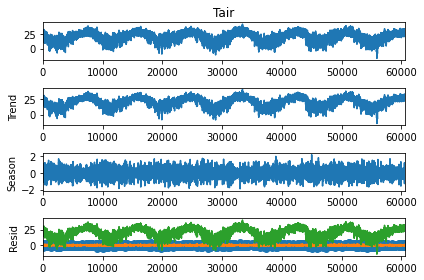

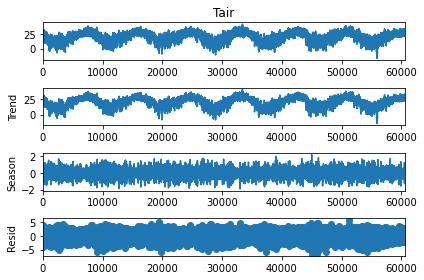

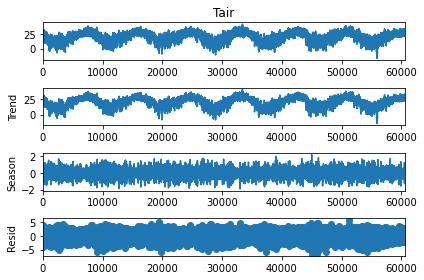

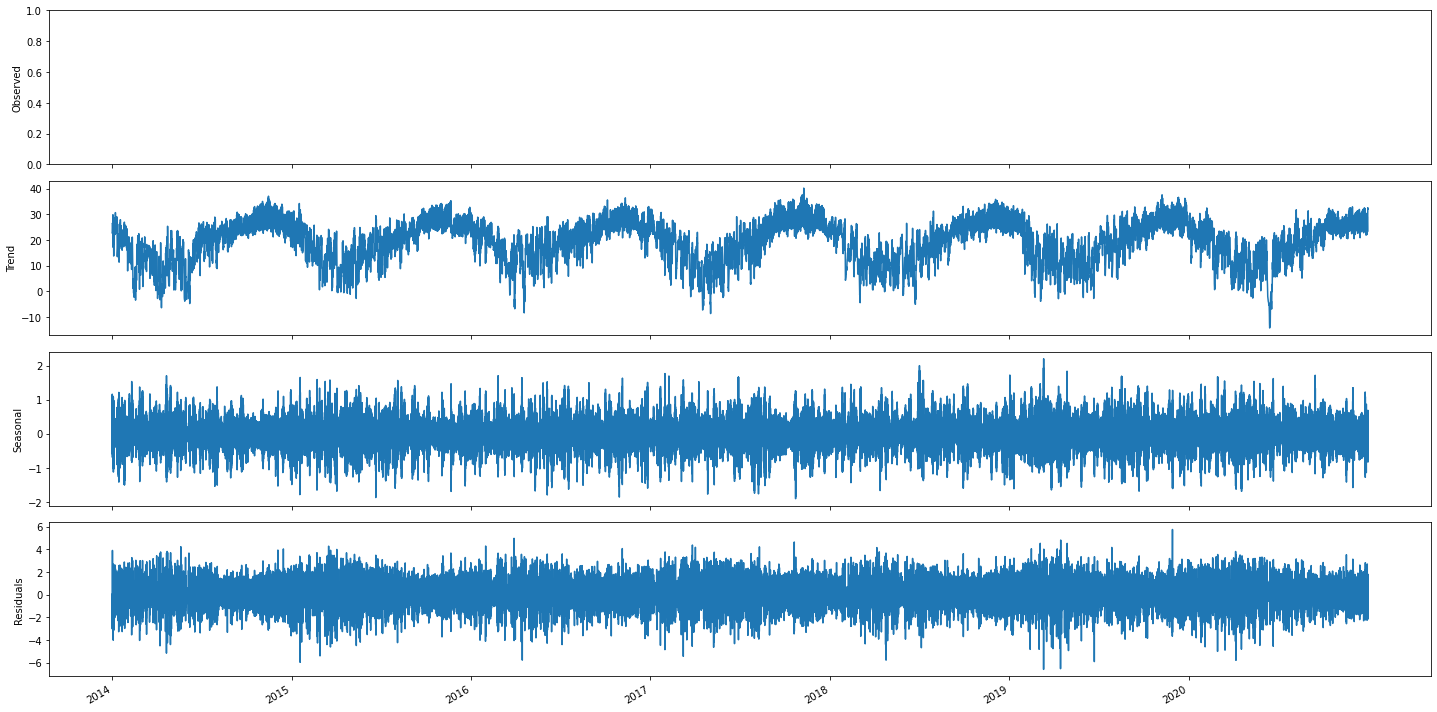

In [11]:
decomposition = STL(met_1.Tair, period=7).fit()
decomposition.plot()
decomposition.seasonal.plot()
decomposition.trend.plot()
decomposition.plot()
decomposition.plot()
decomposition.seasonal
fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(20,10))
ax.plot(decomposition.observed)
ax1.set_ylabel('Observed' )
ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')
ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')
ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')
plt.xticks(np.arange(0, 60649, 8665), np.arange(2014, 2021, 1))
fig.autofmt_xdate()
plt.tight_layout()

#### Station 2

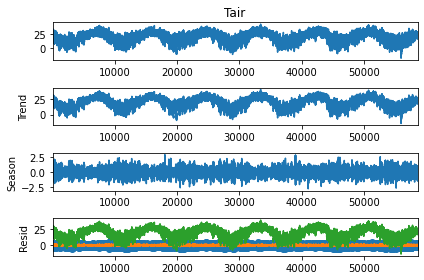

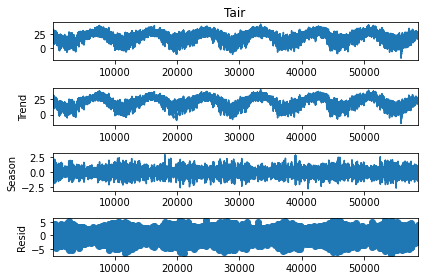

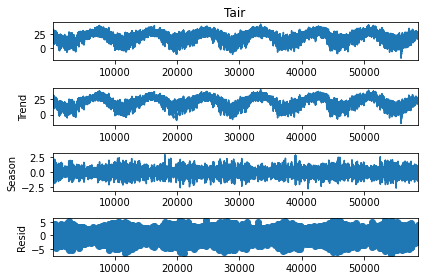

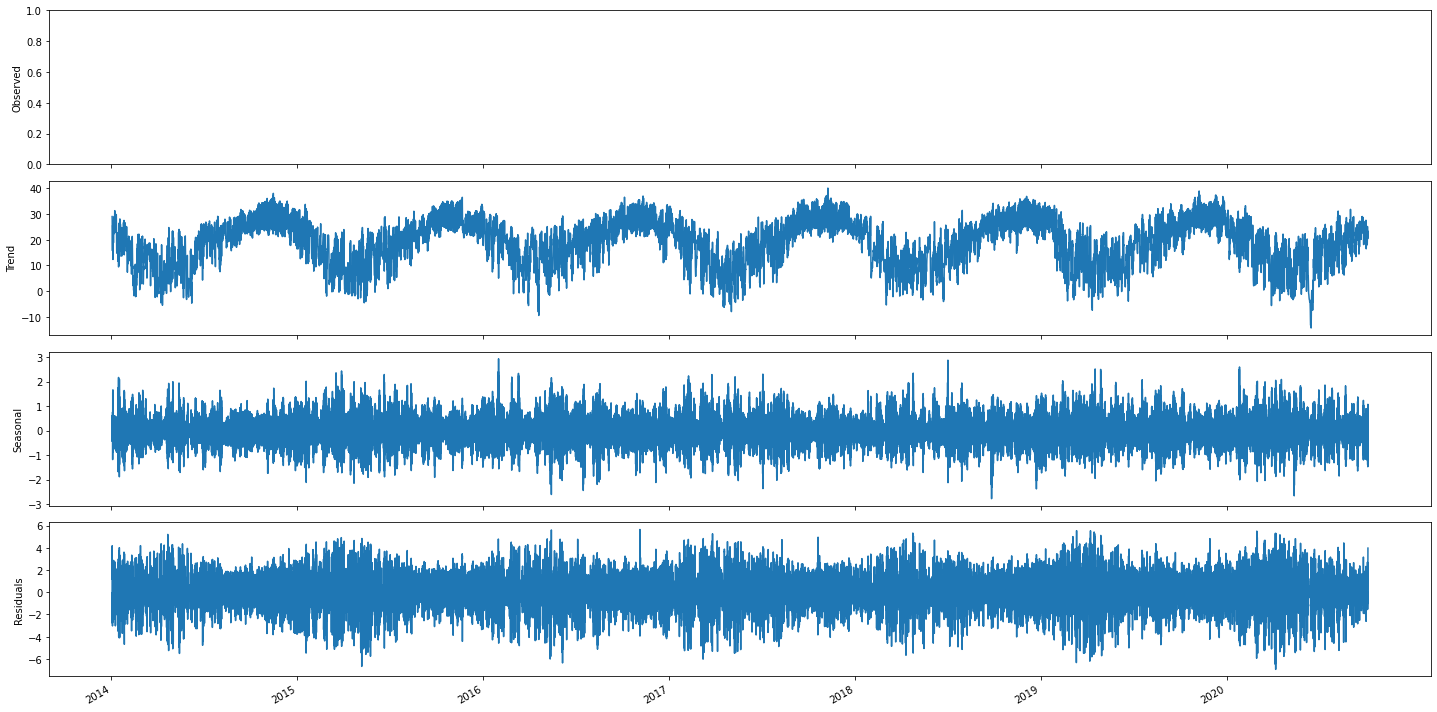

In [12]:
decomposition = STL(met_2.Tair, period=7).fit()
decomposition.plot()
decomposition.seasonal.plot()
decomposition.trend.plot()
decomposition.plot()
decomposition.plot()
decomposition.seasonal
fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(20,10))
ax.plot(decomposition.observed)
ax1.set_ylabel('Observed' )
ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')
ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')
ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')
plt.xticks(np.arange(0, 60649, 8665), np.arange(2014, 2021, 1))
fig.autofmt_xdate()
plt.tight_layout()

#### Station 3

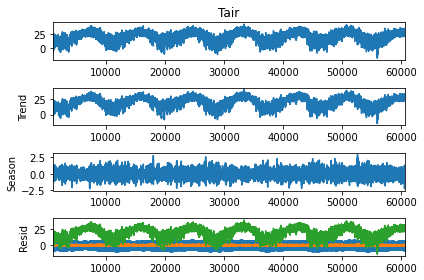

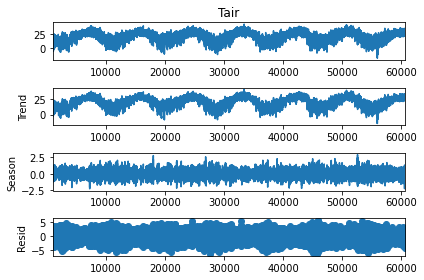

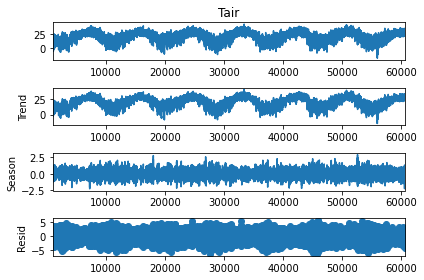

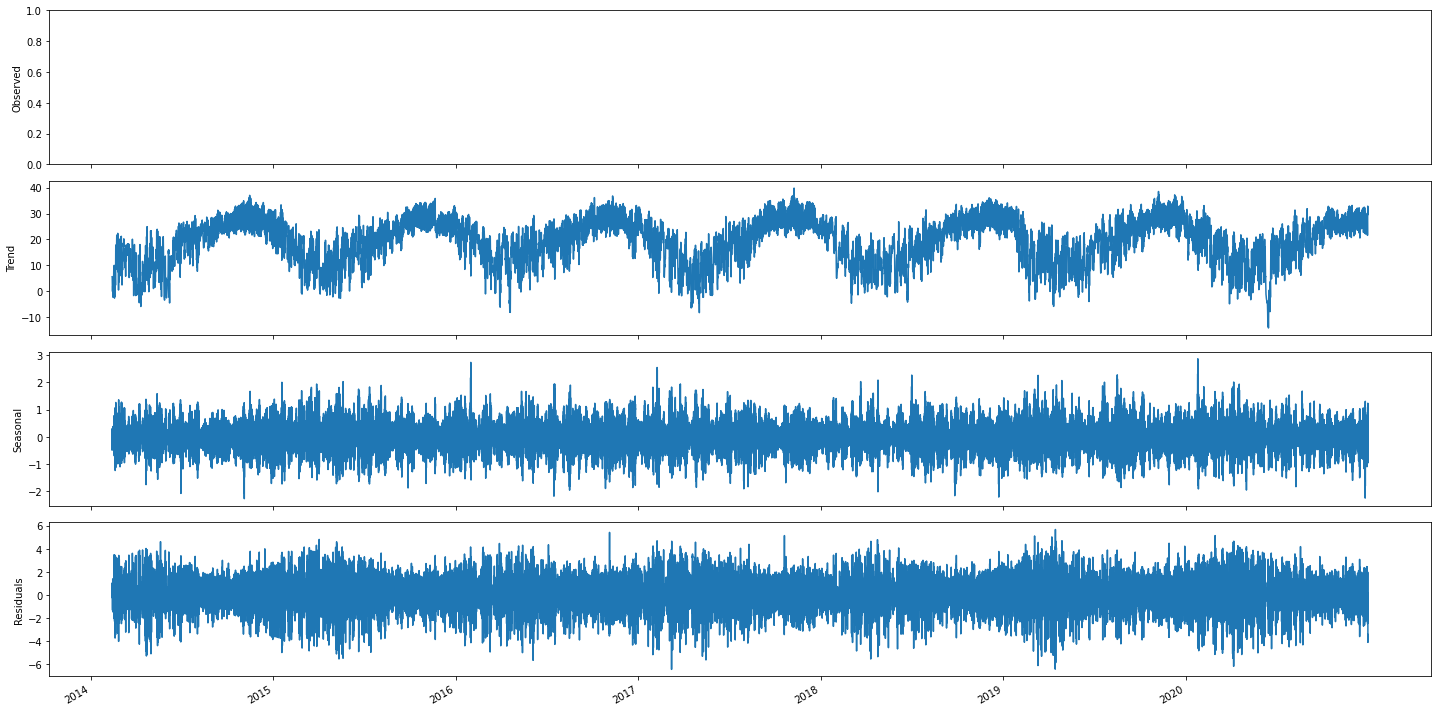

In [13]:
decomposition = STL(met_3.Tair, period=7).fit()
decomposition.plot()
decomposition.seasonal.plot()
decomposition.trend.plot()
decomposition.plot()
decomposition.plot()
decomposition.seasonal
fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(20,10))
ax.plot(decomposition.observed)
ax1.set_ylabel('Observed' )
ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')
ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')
ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')
plt.xticks(np.arange(0, 60649, 8665), np.arange(2014, 2021, 1))
fig.autofmt_xdate()
plt.tight_layout()

#### Station 4

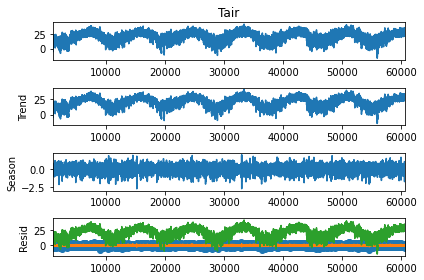

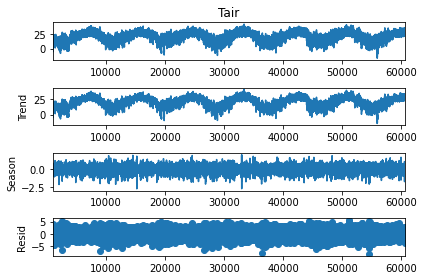

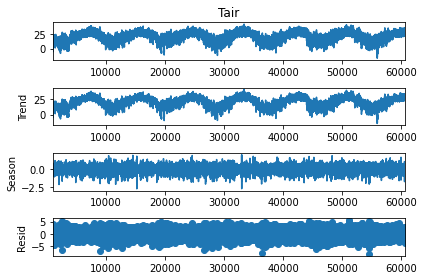

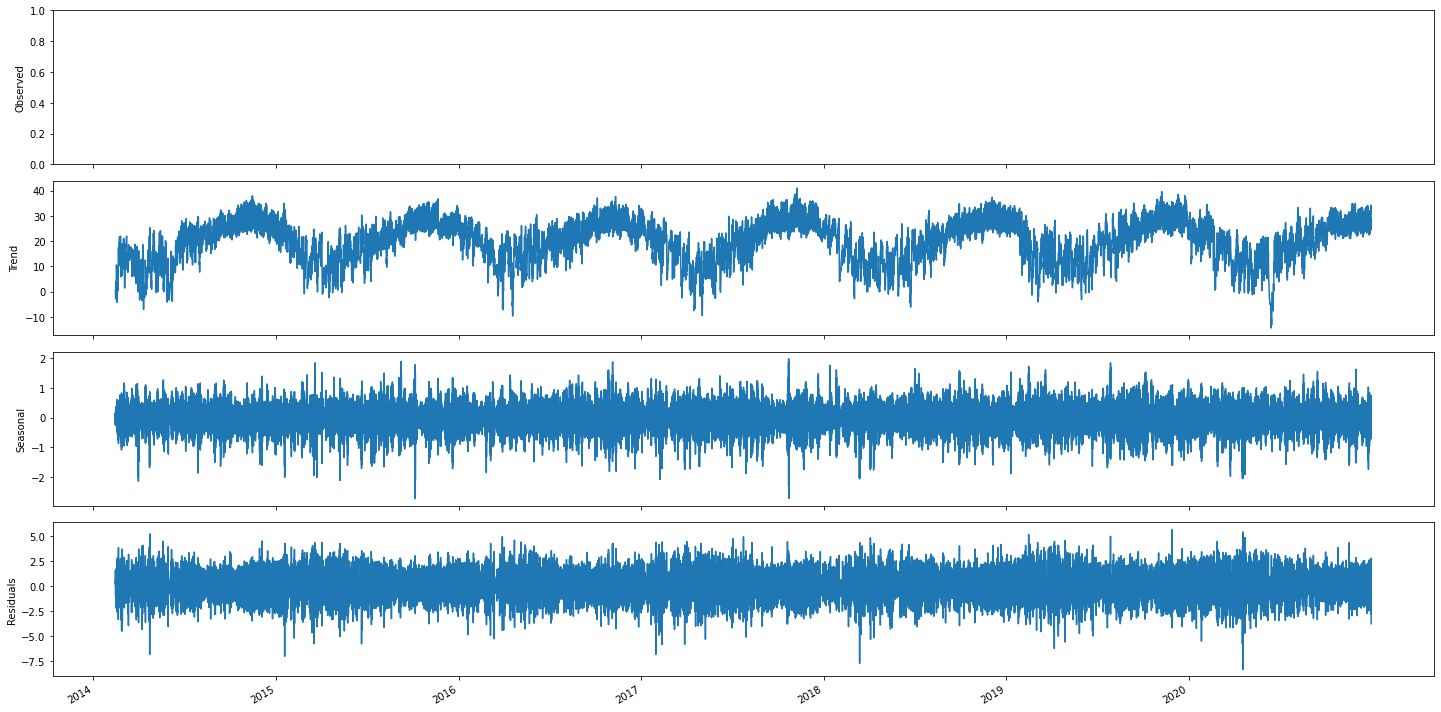

In [14]:
decomposition = STL(met_4.Tair, period=7).fit()
decomposition.plot()
decomposition.seasonal.plot()
decomposition.trend.plot()
decomposition.plot()
decomposition.plot()
decomposition.seasonal
fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(20,10))
ax.plot(decomposition.observed)
ax1.set_ylabel('Observed' )
ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')
ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')
ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')
plt.xticks(np.arange(0, 60649, 8665), np.arange(2014, 2021, 1))
fig.autofmt_xdate()
plt.tight_layout()

#### Station 5

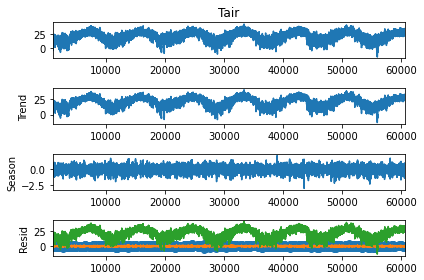

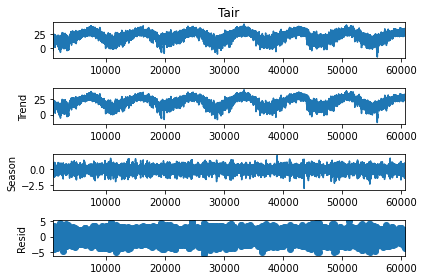

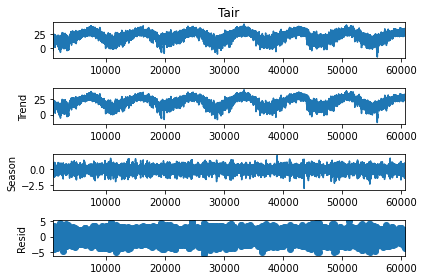

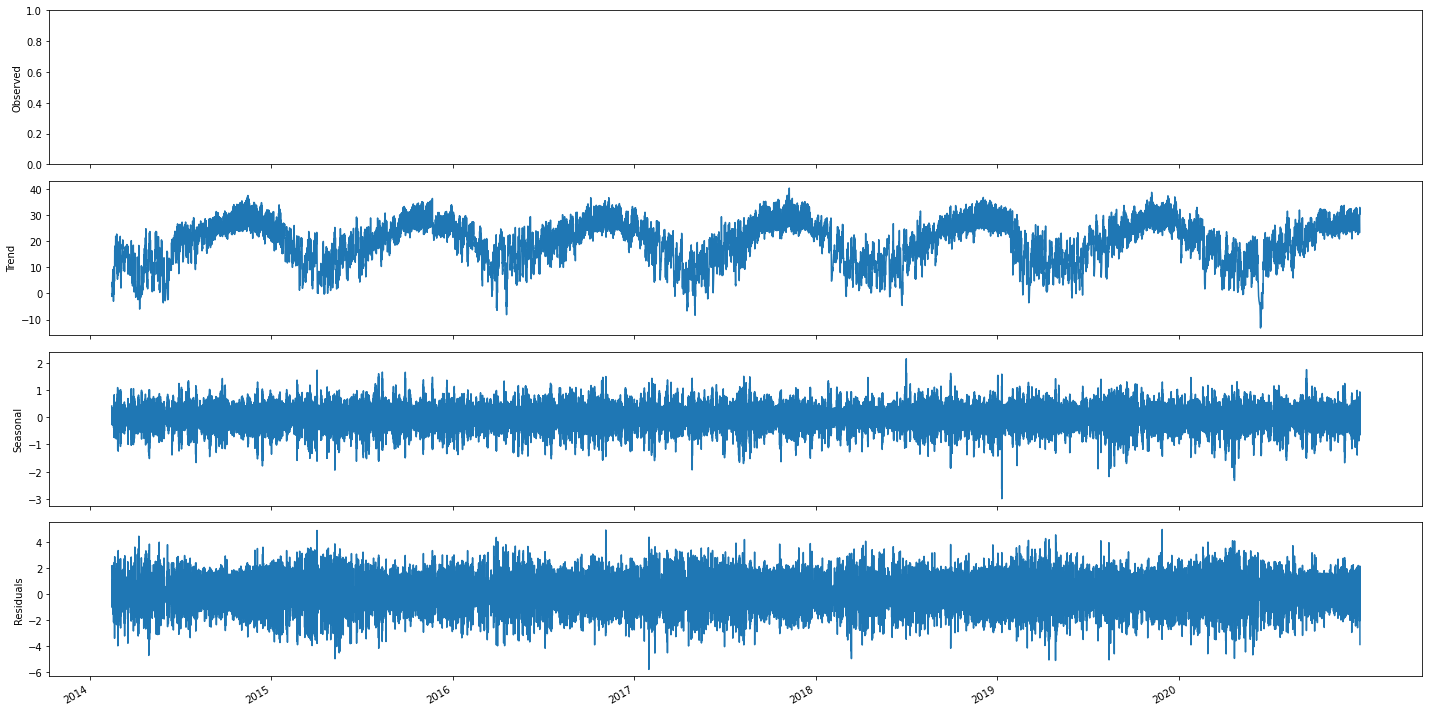

In [15]:
decomposition = STL(met_5.Tair, period=7).fit()
decomposition.plot()
decomposition.seasonal.plot()
decomposition.trend.plot()
decomposition.plot()
decomposition.plot()
decomposition.seasonal
fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(20,10))
ax.plot(decomposition.observed)
ax1.set_ylabel('Observed' )
ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')
ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')
ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')
plt.xticks(np.arange(0, 60649, 8665), np.arange(2014, 2021, 1))
fig.autofmt_xdate()
plt.tight_layout()

#### Station 6

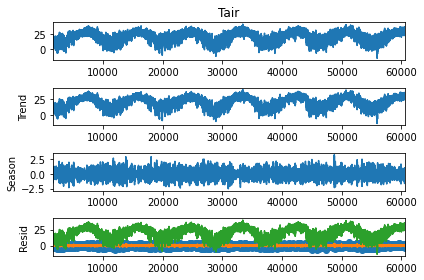

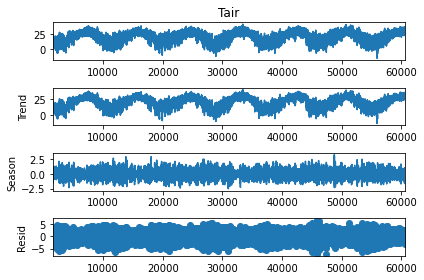

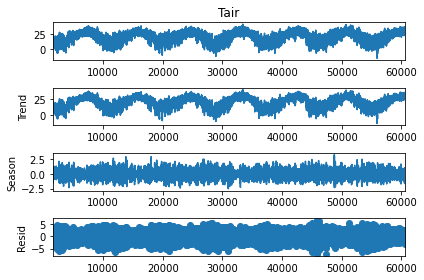

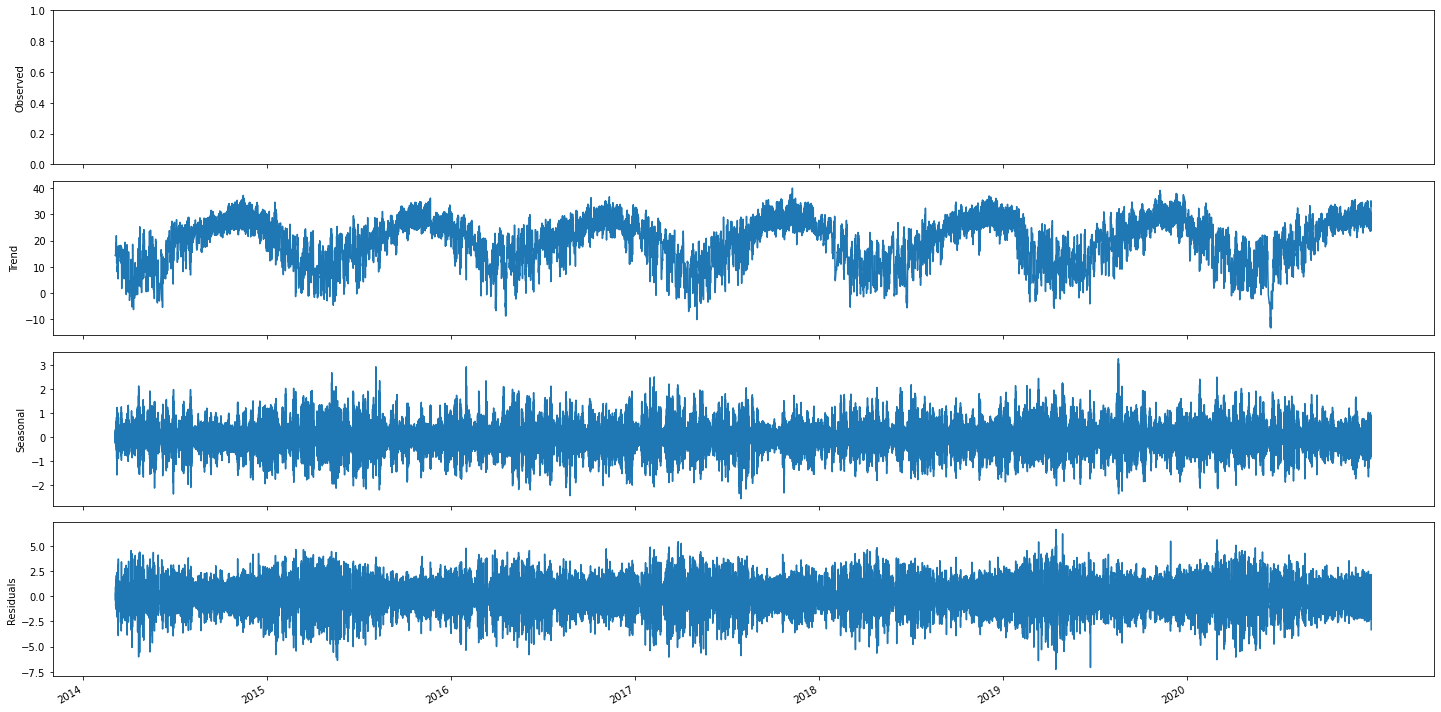

In [16]:
decomposition = STL(met_6.Tair, period=7).fit()
decomposition.plot()
decomposition.seasonal.plot()
decomposition.trend.plot()
decomposition.plot()
decomposition.plot()
decomposition.seasonal
fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(20,10))
ax.plot(decomposition.observed)
ax1.set_ylabel('Observed' )
ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')
ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')
ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')
plt.xticks(np.arange(0, 60649, 8665), np.arange(2014, 2021, 1))
fig.autofmt_xdate()
plt.tight_layout()

### Test for staionary 

In [17]:
# Station 1
stat_test_result = adfuller(met_1.Tair)
print(f'ADF Statistic: {stat_test_result[0]}')
print(f'p-value: {stat_test_result[1]}')

ADF Statistic: -10.194961876227115
p-value: 6.180901170971503e-18


In [18]:
# Station 2
stat_test_result = adfuller(met_2.Tair)
print(f'ADF Statistic: {stat_test_result[0]}')
print(f'p-value: {stat_test_result[1]}')

ADF Statistic: -10.073986251742399
p-value: 1.2376293793724658e-17


In [19]:
# Station 3
stat_test_result = adfuller(met_3.Tair)
print(f'ADF Statistic: {stat_test_result[0]}')
print(f'p-value: {stat_test_result[1]}')

ADF Statistic: -10.011870688569038
p-value: 1.7699144036067098e-17


In [ ]:
# Station 4
stat_test_result = adfuller(met_4.Tair)
print(f'ADF Statistic: {stat_test_result[0]}')
print(f'p-value: {stat_test_result[1]}')

In [ ]:
# Station 5
stat_test_result = adfuller(met_5.Tair)
print(f'ADF Statistic: {stat_test_result[0]}')
print(f'p-value: {stat_test_result[1]}')

In [ ]:
# Station 6
stat_test_result = adfuller(met_6.Tair)
print(f'ADF Statistic: {stat_test_result[0]}')
print(f'p-value: {stat_test_result[1]}')

### Order integration of one

In [ ]:
# Station 1
# Difference the series
y_dff = np.diff(met_1.Tair, n=1)
# Test for staionary
stat_test_result = adfuller(y_dff)
print(f'ADF Statistic: {stat_test_result[0]}')
print(f'p-value: {stat_test_result[1]}')

In [ ]:
# Station 2
# Difference the series
y_dff = np.diff(met_1.Tair, n=1)
# Test for staionary
stat_test_result = adfuller(y_dff)
print(f'ADF Statistic: {stat_test_result[0]}')
print(f'p-value: {stat_test_result[1]}')

In [ ]:
# Station 3
# Difference the series
y_dff = np.diff(met_1.Tair, n=1)
# Test for staionary
stat_test_result = adfuller(y_dff)
print(f'ADF Statistic: {stat_test_result[0]}')
print(f'p-value: {stat_test_result[1]}')

In [ ]:
# Station 4
# Difference the series
y_dff = np.diff(met_1.Tair, n=1)
# Test for staionary
stat_test_result = adfuller(y_dff)
print(f'ADF Statistic: {stat_test_result[0]}')
print(f'p-value: {stat_test_result[1]}')

In [ ]:
# Station 5
# Difference the series
y_dff = np.diff(met_1.Tair, n=1)
# Test for staionary
stat_test_result = adfuller(y_dff)
print(f'ADF Statistic: {stat_test_result[0]}')
print(f'p-value: {stat_test_result[1]}')

In [ ]:
# Station 6
# Difference the series
y_dff = np.diff(met_1.Tair, n=1)
# Test for staionary
stat_test_result = adfuller(y_dff)
print(f'ADF Statistic: {stat_test_result[0]}')
print(f'p-value: {stat_test_result[1]}')

In [ ]:
# Train/test split
'''
(59795, 7)
(57711, 7)
(58878, 7)
(58859, 7)
(58854, 7)
(58380, 7)
'''
train_num1 = int(59795 * 0.8)
test_num1 = 59795 - train_num1

train_num2 = int(57711 * 0.8)
test_num2 = 57711 - train_num2

train_num3 = int(58878 * 0.8)
test_num3 = 58878 - train_num3

train_num4 = int(58859 * 0.8)
test_num4 = 58859 - train_num4

train_num5 = int(58854 * 0.8)
test_num5 = 58854 - train_num5

train_num6 = int(58380 * 0.8)
test_num6 = 58380 - train_num6

# print(train_num)
train_1 = met_1.Tair[:train_num1]
test_1 = met_1.Tair[train_num1:]

train_2 = met_2.Tair[:train_num2]
test_2 = met_2.Tair[train_num2:]

train_3 = met_3.Tair[:train_num3]
test_3 = met_3.Tair[train_num3:]

train_4 = met_4.Tair[:train_num4]
test_4 = met_4.Tair[train_num4:]

train_5 = met_5.Tair[:train_num5]
test_5 = met_5.Tair[train_num5:]

train_6 = met_6.Tair[:train_num6]
test_6 = met_6.Tair[train_num6:]

### Visualize train and test set

In [ ]:
# Station 1
fig,ax = plt.subplots()
ax.plot(met_1.Tair)
ax.set_xlabel('Date')
ax.set_ylabel('Air Temperature')
ax.axvspan(48519, 60649, color='#808080', alpha=0.2)
plt.xticks(np.arange(0, 60649, 8760), np.arange(2014, 2021, 1))
fig.autofmt_xdate()
plt.tight_layout()

In [ ]:
# Station 2
fig,ax = plt.subplots()
ax.plot(met_2.Tair)
ax.set_xlabel('Date')
ax.set_ylabel('Air Temperature')
ax.axvspan(48519, 60649, color='#808080', alpha=0.2)
plt.xticks(np.arange(0, 60649, 8760), np.arange(2014, 2021, 1))
fig.autofmt_xdate()
plt.tight_layout()

In [ ]:
# Station 3
fig,ax = plt.subplots()
ax.plot(met_3.Tair)
ax.set_xlabel('Date')
ax.set_ylabel('Air Temperature')
ax.axvspan(48519, 60649, color='#808080', alpha=0.2)
plt.xticks(np.arange(0, 60649, 8760), np.arange(2014, 2021, 1))
fig.autofmt_xdate()
plt.tight_layout()

In [ ]:
# Station 4
fig,ax = plt.subplots()
ax.plot(met_4.Tair)
ax.set_xlabel('Date')
ax.set_ylabel('Air Temperature')
ax.axvspan(48519, 60649, color='#808080', alpha=0.2)
plt.xticks(np.arange(0, 60649, 8760), np.arange(2014, 2021, 1))
fig.autofmt_xdate()
plt.tight_layout()

In [ ]:
# Station 5
fig,ax = plt.subplots()
ax.plot(met_5.Tair)
ax.set_xlabel('Date')
ax.set_ylabel('Air Temperature')
ax.axvspan(48519, 60649, color='#808080', alpha=0.2)
plt.xticks(np.arange(0, 60649, 8760), np.arange(2014, 2021, 1))
fig.autofmt_xdate()
plt.tight_layout()

In [ ]:
# Station 6
fig,ax = plt.subplots()
ax.plot(met_6.Tair)
ax.set_xlabel('Date')
ax.set_ylabel('Air Temperature')
ax.axvspan(48519, 60649, color='#808080', alpha=0.2)
plt.xticks(np.arange(0, 60649, 8760), np.arange(2014, 2021, 1))
fig.autofmt_xdate()
plt.tight_layout()

In [ ]:
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX
def optimize_SARIMAX(endog: Union[pd.Series, list], exog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm_notebook(order_list) :
        try:
            model = SARIMAX(
            endog,
            exog,
            order=(order[0],d, order[1]),
            seasonal_order=(order [2], D, order[3],s),
            simple_differencing=False).fit(disp=False)
        except:
            continue
            
        results.append([order, model.aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p, q, P, Q)','AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    return result_df

In [ ]:
# Define range of values for p, q, P and l
ps = range(0, 7, 1)
qs = range(0, 7, 1)
Ps = range(0, 7, 1)
Qs = range(0, 7, 1)
# Create list of all unique combinations
order_list = list(product(ps, qs, Ps, Qs))
# Set constants
d = 1
D = 1
s = 8760

In [ ]:
# Station 1
# Find the (p,d, q) (P, D,O) m combination with the lowest AIC
# This takes verv lona to run (about 30 min)
# The resulting order should be: p=2, q=3, P=1, 0=3

SARIMA_result_df = optimize_SARIMAX(train_1, None, order_list, d, D, s)
SARIMA_result_df

  0%|          | 0/2401 [00:00<?, ?it/s]

In [ ]:
# Fit optimal model to study its residuals

SARIMA_model = SARIMAX(train_1, order=(2,1,3), seasonal_order=(1,1,3,12), simple_differencing=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)

# Print model summary
print(SARIMA_model_fit.summary())

In [ ]:
# Plot risidual's diagnostics
SARIMA_model_fit.plot_diagnostics(figsize = (10,8));

In [ ]:
# Ljung-box test
residuals = SARIMA_model_fit.resid
lbvalue, pvalue = acorr_ljungbox (residuals, np.arange (1, 11, 1))
# Print p-values
print(pvalue)

In [ ]:
# Forcasting
# Function to perform rolling forecasts
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str) -> list:
    total_len = train_len + horizon
    end_idx = train_len
                     
    if method == "last_season":
        pred_last_season = []
                     
        for i in range (train_len, total_len, window):
            last_season = df['dcoilwtico'][i-window:i].values
            pred_last_season.extend(last_season)
        return pred_last_season
                                  
    elif method == "SARIMA":
        pred_SARIMA = []
        
        for i in range (train_len, total_len, window):
            model = SARIMAX(df['dcoilwtico'][:i], order=(2,1,3) , seasonal_order=(1,1,3,365),simple_differencing=False)
            res = model.fit(disp=False)
            predictions = res.get_prediction (0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_SARIMA.extend(oos_pred)
        return pred_SARIMA

In [ ]:
pred_df = met_1[47836:]

pred_df